[*********************100%***********************]  1 of 1 completed


Backtest result -    AAPL:
strategy SMA 20 X SMA 50 crossover
Period :                  2020-01-01-> 2024-12-31
Starting capital :        $100000.000000
Final portfolio:          $207651.762589
Total return;             107.651763%
Buy&Hold return:          273.454473%
annualised return:        16.465998%
sharpe ratio:             0.829699
max drawdown:             -29.093513%
Total trade:              13
win rate :                61.538462%
Chart saved → /Users/rishavyadav/rishav_irage/backtest_report.png


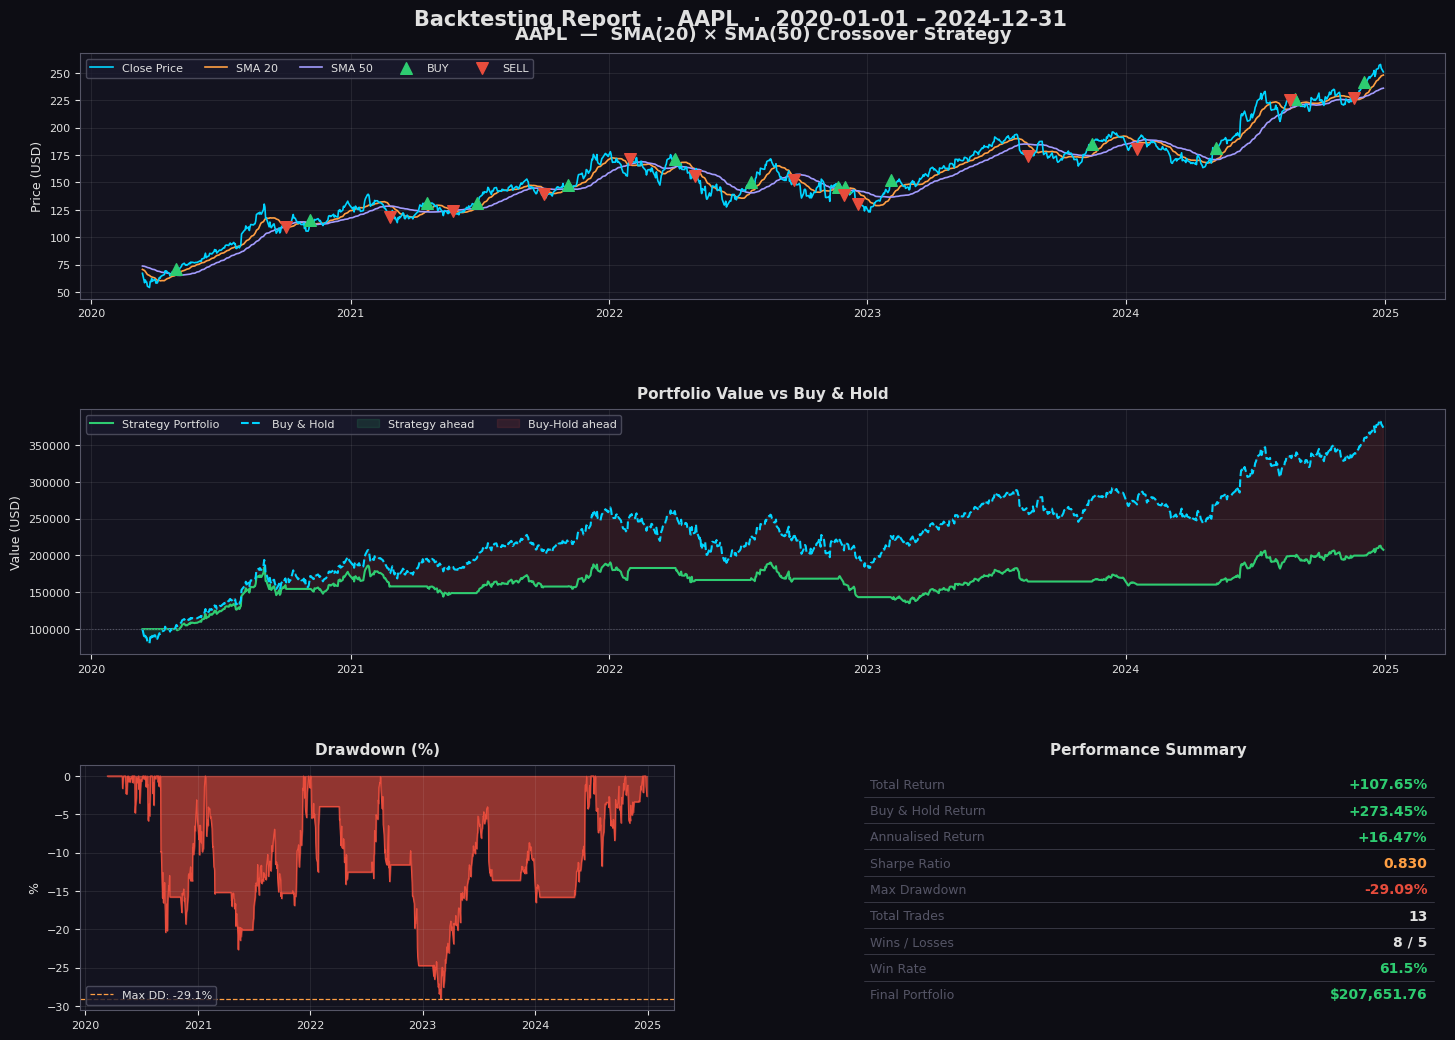

In [104]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import os 
from datetime import datetime


# input 
stocks = input('Enter the symbol of stock')
start= input(f"Enter the start date ({"%Y-%m-%d"}):")
end = input(f"Enter the end date ({"%Y-%m-%d"}):")
INITIAL_CASH = int(input("Enter initial cash: "))        
SHORT_WINDOW = int(input("Enter short SMA: "))             
LONG_WINDOW  = int(input("Enter long SMA: "))  


# fetch data from y finance


data = yf.download(stocks,start,end)
df = pd.DataFrame(data)

df["SMA_short"] = df["Close"].rolling(SHORT_WINDOW).mean()
df["SMA_long"]  = df["Close"].rolling(LONG_WINDOW).mean()
df.dropna(inplace=True)


# Signal: 1 = hold long   0 = inn cash
df["Signal"]   = np.where(df["SMA_short"] > df["SMA_long"], 1, 0)
df["Position"] = df["Signal"].diff()   # +1 = Buy -1 = sell

#backtest
cash   = INITIAL_CASH
shares = 0
portfolio = []
trade_log = []

for date, row in df.iterrows():
    price = float(row["Close"].iloc[0])
    pos = float(row["Position"].iloc[0])

    if pos == 1.0 and cash > 0: # Buy signal
        shares = cash / price
        cash = 0
        trade_log.append({"Date": date,
                          "Action": "BUY" , 
                          "Price": price,
                          "Shares": shares})

    elif pos == -1.0 and shares > 0:   # Sell signal
        cash = shares * price
        trade_log.append({"Date": date, 
                          "Action": "SELL",
                          "Price": price,
                          "Value": cash,
                          "Shares": shares})
        shares = 0

    total = cash + shares * price
    portfolio.append(total)

df["Portfolio"] = portfolio

#   buy and hold 
df["BuyHold"] = INITIAL_CASH * (df["Close"] / df["Close"].iloc[0])


# Performance metrices

final_val = df["Portfolio"].iloc[-1]
bh_val = df["BuyHold"].iloc[-1]
total_ret = (final_val - INITIAL_CASH) / INITIAL_CASH * 100
bh_ret = (bh_val - INITIAL_CASH) / INITIAL_CASH * 100



# Annual return
n_years = len(df) / 252
ann_ret = ((final_val / INITIAL_CASH) ** (1 / n_years) - 1) * 100

# daily returns
daily_ret = df["Portfolio"].pct_change().dropna()
sharpe = (daily_ret.mean() / daily_ret.std()) * np.sqrt(252)

# drawdown
rolling_max = df["Portfolio"].cummax()
drawdown = (df["Portfolio"] - rolling_max) / rolling_max
max_dd = drawdown.min() * 100


# Win rate
trades = pd.DataFrame(trade_log)
wins = 0
losses = 0
buy_price = None
for i, t in trades.iterrows():
    if t["Action"] == "BUY":
        buy_price = t["Price"]
    elif t["Action"] == "SELL" and buy_price:
        if t["Price"] > buy_price:
            wins += 1
        else:
            losses += 1
total_trades = wins + losses
win_rate     = (wins / total_trades * 100) 


print(f"Backtest result -    {stocks}:")
print(f"strategy SMA {SHORT_WINDOW} X SMA {LONG_WINDOW} crossover")
print(f"Period :                  {start}-> {end}")
print(f"Starting capital :        ${INITIAL_CASH:2f}")
print(f"Final portfolio:          ${final_val:2f}")
print(f"Total return;             {total_ret:2f}%")
print(f"Buy&Hold return:          {bh_ret:2f}%")
print(f"annualised return:        {ann_ret:2f}%")
print(f"sharpe ratio:             {sharpe:2f}")
print(f"max drawdown:             {max_dd:2f}%")
print(f"Total trade:              {total_trades}")
print(f"win rate :                {win_rate:2f}%")




# charts
BG = "#0d0d14"
CARD = "#13131f"
CYAN = "#00d4ff"
ORG = "#ff9f43"
GRN = "#2ecc71"
RED = "#e74c3c"
PRP = "#a29bfe"
WHT = "#e0e0e0"
GRY = "#555566"

fig = plt.figure(figsize=(15, 11), facecolor=BG)
gs = gridspec.GridSpec(3, 2, figure=fig,
                        hspace=0.45,
                        wspace=0.3,
                        left=0.06,
                        right=0.97, 
                        top=0.93, 
                        bottom=0.06)

ax_price= fig.add_subplot(gs[0, :])   
ax_port = fig.add_subplot(gs[1, :])  
ax_dd = fig.add_subplot(gs[2, 0])   
ax_metric = fig.add_subplot(gs[2, 1])   

for ax in [ax_price, ax_port, ax_dd, ax_metric]:
    ax.set_facecolor(CARD)
    for sp in ax.spines.values():
        sp.set_edgecolor(GRY)
    ax.tick_params(colors=WHT, labelsize=8)
    ax.grid(alpha=0.08, color="#ffffff")
    

# Price and  sma and  signals
ax_price.plot(df.index, df["Close"], color=CYAN, lw=1.2,label="Close Price",zorder=3)
ax_price.plot(df.index, df["SMA_short"],color=ORG,  lw=1.2,label=f"SMA {SHORT_WINDOW}",zorder=2)
ax_price.plot(df.index, df["SMA_long"],color=PRP,  lw=1.2,label=f"SMA {LONG_WINDOW}",zorder=2)





# Buy and Sell markers
buys = df[df["Position"]==  1]
sells = df[df["Position"] == -1]
ax_price.scatter(buys.index,  buys["Close"],marker="^", color=GRN, s=70, zorder=5, label="BUY")
ax_price.scatter(sells.index, sells["Close"], marker="v", color=RED, s=70, zorder=5, label="SELL")

ax_price.set_title(f"{stocks}  —  SMA({SHORT_WINDOW}) × SMA({LONG_WINDOW}) Crossover Strategy",
                   color=WHT, fontsize=13, fontweight="bold", pad=10)
ax_price.set_ylabel("Price (USD)", color=WHT, fontsize=9)
ax_price.legend(facecolor="#1a1a2e", edgecolor=GRY, labelcolor=WHT, fontsize=8, ncol=5)



#portfolio vs buyhold 
ax_port.plot(df.index, df["Portfolio"], color=GRN,  lw=1.5, label="Strategy Portfolio")
ax_port.plot(df.index, df["BuyHold"],   color=CYAN, lw=1.5, label="Buy & Hold", linestyle="--")
ax_port.axhline(INITIAL_CASH, color=GRY, lw=0.8, linestyle=":")
ax_port.fill_between(df.index,
                     df["Portfolio"], df["BuyHold"],
                     where=df["Portfolio"] >= df["BuyHold"],
                     alpha=0.12, color=GRN, label="Strategy ahead")
ax_port.fill_between(df.index,
                     df["Portfolio"], df["BuyHold"],
                     where=df["Portfolio"] <  df["BuyHold"],
                     alpha=0.12, color=RED, label="Buy-Hold ahead")
ax_port.set_title("Portfolio Value vs Buy & Hold", color=WHT, fontsize=11, fontweight="bold", pad=8)
ax_port.set_ylabel("Value (USD)", color=WHT, fontsize=9)
ax_port.legend(facecolor="#1a1a2e", edgecolor=GRY, labelcolor=WHT, fontsize=8, ncol=4)


# Drawdown
ax_dd.fill_between(df.index, drawdown * 100, 0, color=RED, alpha=0.6)
ax_dd.plot(df.index, drawdown * 100, color=RED, lw=0.8)
ax_dd.axhline(max_dd, color=ORG, lw=0.9, linestyle="--",
              label=f"Max DD: {max_dd:.1f}%")
ax_dd.set_title("Drawdown (%)", color=WHT, fontsize=11, fontweight="bold", pad=8)
ax_dd.set_ylabel("%", color=WHT, fontsize=9)
ax_dd.legend(facecolor="#1a1a2e", edgecolor=GRY, labelcolor=WHT, fontsize=8)


#Metrics card
ax_metric.axis("off")
metrics = [
    ("Total Return",f"{total_ret:+.2f}%",GRN if total_ret > 0 else RED),
    ("Buy & Hold Return",f"{bh_ret:+.2f}%",GRN if bh_ret > 0 else RED),
    ("Annualised Return",f"{ann_ret:+.2f}%",GRN if ann_ret > 0 else RED),
    ("Sharpe Ratio",f"{sharpe:.3f}", GRN if sharpe > 1 else ORG),
    ("Max Drawdown",f"{max_dd:.2f}%",RED),
    ("Total Trades",f"{total_trades}",WHT),
    ("Wins / Losses",f"{wins} / {losses}",WHT),
    ("Win Rate",f"{win_rate:.1f}%",GRN if win_rate >= 50 else RED),
    ("Final Portfolio",f"${final_val:,.2f}",GRN if final_val > INITIAL_CASH else RED)
    ]

# Performace table 
ax_metric.set_title("Performance Summary", color=WHT, fontsize=11,
                    fontweight="bold", pad=8)
for i, (label, value, color) in enumerate(metrics):
    y = 0.92 - i * 0.107
    ax_metric.text(0.03, y, label,  transform=ax_metric.transAxes,
                   color=GRY, fontsize=9, va="center")
    ax_metric.text(0.97, y, value,  transform=ax_metric.transAxes,
                   color=color, fontsize=10, va="center", ha="right", fontweight="bold")
    if i < len(metrics) - 1:
        ax_metric.plot([0.02, 0.98], [y - 0.05, y - 0.05],
                       color=GRY, lw=0.4, transform=ax_metric.transAxes)

fig.suptitle(f"Backtesting Report  ·  {stocks}  ·  {start} – {end}",
             color=WHT, fontsize=15, fontweight="bold", y=0.97)



# save the chart 
out = "backtest_report.png"  
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=BG)
print(f"Chart saved → {os.path.abspath(out)}")


